In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

GauCare libraries imported successfully.
GauCare configuration loaded.
Training shape: (3840, 19)
Testing shape: (960, 19)
Training columns: ['conductivity_raw_mScm', 'temperature_C', 'conductivity_temp_adjusted_mScm', 'as7343_F1', 'as7343_F2', 'as7343_FZ', 'as7343_F3', 'as7343_F4', 'as7343_F5', 'as7343_FY', 'as7343_FXL', 'as7343_F6', 'as7343_F7', 'as7343_F8', 'as7343_NIR', 'as7343_VIS', 'as7343_FD', 'conductivity_deviation', 'risk_label']
Testing columns: ['conductivity_raw_mScm', 'temperature_C', 'conductivity_temp_adjusted_mScm', 'as7343_F1', 'as7343_F2', 'as7343_FZ', 'as7343_F3', 'as7343_F4', 'as7343_F5', 'as7343_FY', 'as7343_FXL', 'as7343_F6', 'as7343_F7', 'as7343_F8', 'as7343_NIR', 'as7343_VIS', 'as7343_FD', 'conductivity_deviation', 'risk_label']

Training dataset shape: (3840, 19)
Testing dataset shape: (960, 19)

Training data types:
conductivity_raw_mScm              float64
temperature_C                      float64
conductivity_temp_adjusted_mScm    float64
as7343_F1       

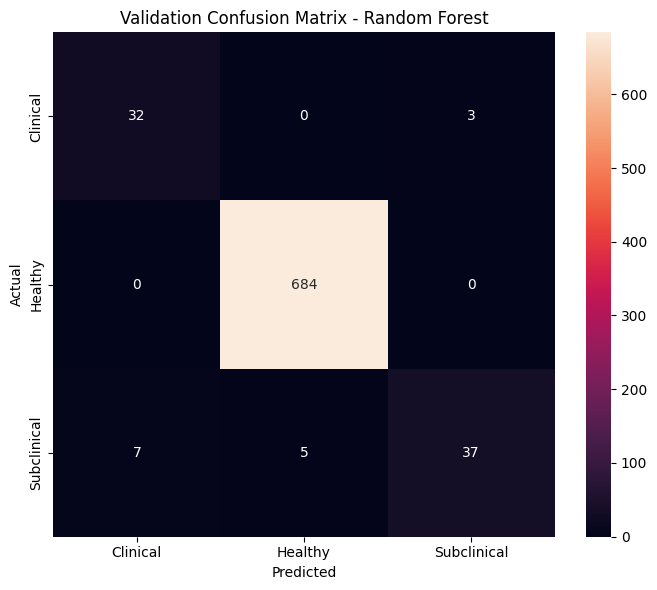


Feature importance (highest to lowest):
                        Feature  Importance
          conductivity_raw_mScm    0.201904
         conductivity_deviation    0.123022
conductivity_temp_adjusted_mScm    0.118672
                  temperature_C    0.097765
                      as7343_F7    0.055865
                      as7343_F8    0.048680
                      as7343_FZ    0.047778
                     as7343_NIR    0.042434
                     as7343_VIS    0.041182
                      as7343_F2    0.037758
                      as7343_F3    0.035662
                      as7343_F1    0.031700
                     as7343_FXL    0.029780
                      as7343_F6    0.024720
                      as7343_FD    0.019387
                      as7343_FY    0.017381
                      as7343_F4    0.014527
                      as7343_F5    0.011783


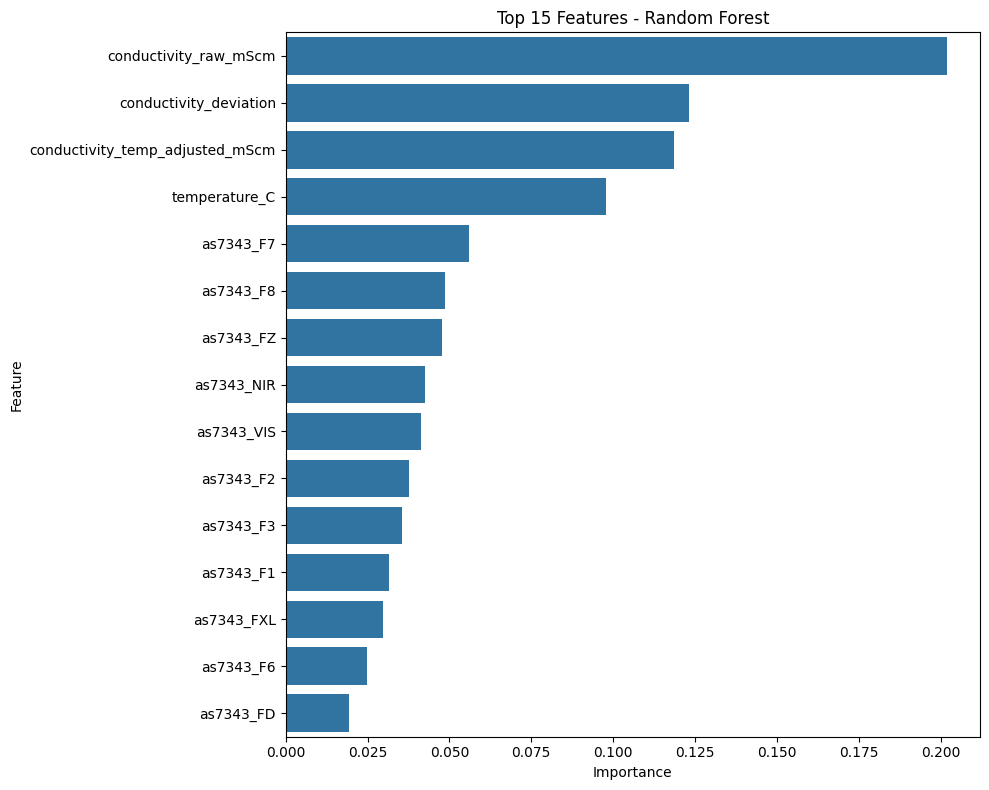


Final test evaluation on unseen dataset
Test Accuracy: 0.9854
Test Macro Precision: 0.9364
Test Macro Recall: 0.9231
Test Macro F1: 0.9296

Test classification report:
              precision    recall  f1-score   support

    Clinical       0.93      0.89      0.91        44
     Healthy       1.00      1.00      1.00       855
 Subclinical       0.89      0.89      0.89        61

    accuracy                           0.99       960
   macro avg       0.94      0.92      0.93       960
weighted avg       0.99      0.99      0.99       960



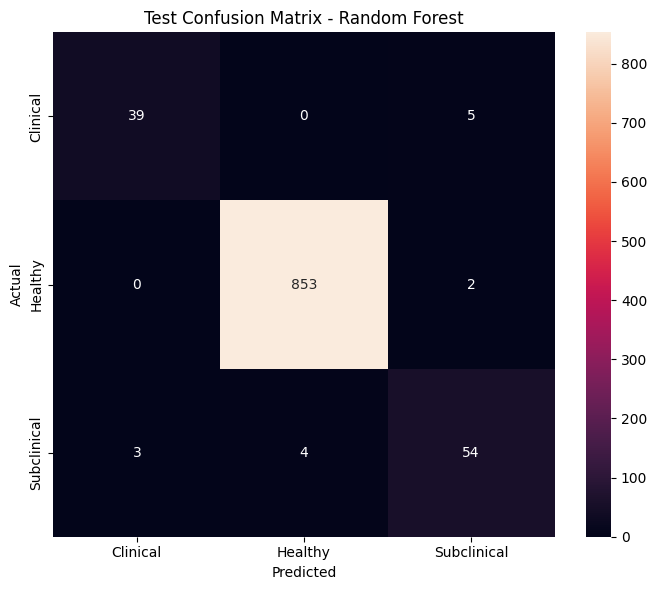


Retraining Random Forest on the complete training dataset...
Final model trained successfully.

Saved model artifacts:
- /content/gaucare_model.pkl
- /content/gaucare_label_encoder.pkl
- /content/gaucare_feature_spec.pkl

Example prediction:
{
    "risk_label": "Healthy",
    "risk_probability": 0.9933333333333333,
    "class_probabilities": {
        "Clinical": 0.0033333333333333335,
        "Healthy": 0.9933333333333333,
        "Subclinical": 0.0033333333333333335
    }
}

Metadata saved to /content/gaucare_model_metadata.json

GauCare artifact verification
gaucare_model.pkl: 3434.80 KB
gaucare_label_encoder.pkl: 0.50 KB
gaucare_feature_spec.pkl: 0.28 KB
gaucare_model_metadata.json: 0.77 KB


In [ ]:
# 2. Imports
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("GauCare libraries imported successfully.")

# 3. Configuration
TRAIN_PATH = "/content/gocare_train_cleaned.csv"
TEST_PATH = "/content/gocare_test_cleaned.csv"
TARGET_COLUMN = "risk_label"

EXPECTED_FEATURES = [
    "conductivity_raw_mScm",
    "temperature_C",
    "conductivity_temp_adjusted_mScm",
    "as7343_F1",
    "as7343_F2",
    "as7343_FZ",
    "as7343_F3",
    "as7343_F4",
    "as7343_F5",
    "as7343_FY",
    "as7343_FXL",
    "as7343_F6",
    "as7343_F7",
    "as7343_F8",
    "as7343_NIR",
    "as7343_VIS",
    "as7343_FD",
    "conductivity_deviation",
]

print("GauCare configuration loaded.")

# 4. Load datasets
if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Training dataset not found: {TRAIN_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Testing dataset not found: {TEST_PATH}")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
print("Training columns:", list(train_df.columns))
print("Testing columns:", list(test_df.columns))

# 5. Dataset audit
if train_df is None or test_df is None:
    raise ValueError("Training and test datasets must be loaded before auditing.")

required_columns = [TARGET_COLUMN] + EXPECTED_FEATURES
missing_in_train = [column for column in required_columns if column not in train_df.columns]
missing_in_test = [column for column in required_columns if column not in test_df.columns]
missing_columns = {
    "train": missing_in_train,
    "test": missing_in_test,
}
if missing_in_train or missing_in_test:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("\nTraining dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)
print("\nTraining data types:")
print(train_df.dtypes)
print("\nFirst 5 training rows:")
print(train_df.head().to_string(index=False))
print("\nMissing values in training data:")
print(train_df.isnull().sum())
print("\nTarget class distribution:")
print(train_df[TARGET_COLUMN].value_counts())
print("\nTarget percentages:")
print(train_df[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2).to_string())

# 6. Feature selection
FEATURE_COLUMNS = EXPECTED_FEATURES.copy()

X = train_df[FEATURE_COLUMNS].copy()
y = train_df[TARGET_COLUMN].copy()

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET_COLUMN].copy()

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Test feature matrix shape:", X_test.shape)
print("Test target shape:", y_test.shape)

# 7. Target encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

print("\nClass mapping:")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"{index} -> {class_name}")

# 8. Train/validation split
print("\nInternal validation split (80/20 stratified)")
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded,
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Final unseen test samples: {len(X_test)}")

# 9. Preprocessing
preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
print("\nPreprocessing pipeline created.")

# 10. Model definition
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_split=2,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                XGBClassifier(
                    n_estimators=300,
                    max_depth=5,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="multi:softprob",
                    eval_metric="mlogloss",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

print("\nBaseline models defined:")
for name in models:
    print(f"- {name}")

# 11. Model training
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

# 12. Model comparison
results = []
for name, model in trained_models.items():
    val_predictions = model.predict(X_val)
    accuracy = accuracy_score(y_val, val_predictions)
    precision = precision_score(y_val, val_predictions, average="macro", zero_division=0)
    recall = recall_score(y_val, val_predictions, average="macro", zero_division=0)
    f1 = f1_score(y_val, val_predictions, average="macro", zero_division=0)
    results.append(
        {
            "Model": name,
            "Accuracy": accuracy,
            "Macro Precision": precision,
            "Macro Recall": recall,
            "Macro F1": f1,
        }
    )

results_df = pd.DataFrame(results).sort_values(by="Macro F1", ascending=False)
print("\nModel comparison (sorted by Macro F1):")
print(results_df.to_string(index=False))

# 13. Validation evaluation
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
validation_predictions = best_model.predict(X_val)

print(f"\nBest model selected on internal validation set: {best_model_name}")
print(f"Validation Macro F1: {results_df.iloc[0]['Macro F1']:.4f}")
print("\nValidation classification report:")
print(
    classification_report(
        y_val,
        validation_predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

cm = confusion_matrix(y_val, validation_predictions)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title(f"Validation Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 14. Feature importance
classifier = best_model.named_steps["classifier"]
if hasattr(classifier, "feature_importances_"):
    importance_df = pd.DataFrame(
        {
            "Feature": FEATURE_COLUMNS,
            "Importance": classifier.feature_importances_,
        }
    ).sort_values(by="Importance", ascending=False)
    print("\nFeature importance (highest to lowest):")
    print(importance_df.to_string(index=False))

    top_features = importance_df.head(15)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x="Importance", y="Feature")
    plt.title(f"Top 15 Features - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"\n{best_model_name} does not support feature_importances_.")

# 15. Final test evaluation
print("\nFinal test evaluation on unseen dataset")
test_predictions = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test_encoded, test_predictions)
test_precision = precision_score(y_test_encoded, test_predictions, average="macro", zero_division=0)
test_recall = recall_score(y_test_encoded, test_predictions, average="macro", zero_division=0)
test_f1 = f1_score(y_test_encoded, test_predictions, average="macro", zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall: {test_recall:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("\nTest classification report:")
print(
    classification_report(
        y_test_encoded,
        test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

test_cm = confusion_matrix(y_test_encoded, test_predictions)
plt.figure(figsize=(7, 6))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title(f"Test Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 16. Final model training
print(f"\nRetraining {best_model_name} on the complete training dataset...")
best_model.fit(X, y_encoded)
print("Final model trained successfully.")

# 17. Model export
MODEL_PATH = "/content/gaucare_model.pkl"
ENCODER_PATH = "/content/gaucare_label_encoder.pkl"
FEATURE_PATH = "/content/gaucare_feature_spec.pkl"

joblib.dump(best_model, MODEL_PATH)
joblib.dump(label_encoder, ENCODER_PATH)
joblib.dump(FEATURE_COLUMNS, FEATURE_PATH)

print("\nSaved model artifacts:")
print(f"- {MODEL_PATH}")
print(f"- {ENCODER_PATH}")
print(f"- {FEATURE_PATH}")

# 18. Prediction function
def predict_risk(scan_data):
    """Predict the risk label and probabilities for a single GauCare scan."""
    if not isinstance(scan_data, dict):
        raise TypeError("scan_data must be a dictionary of feature values.")

    missing = [feature for feature in FEATURE_COLUMNS if feature not in scan_data]
    if missing:
        raise ValueError(f"Missing required feature values: {missing}")

    input_df = pd.DataFrame([scan_data], columns=FEATURE_COLUMNS)
    encoded_prediction = best_model.predict(input_df)[0]
    predicted_label = label_encoder.inverse_transform([encoded_prediction])[0]
    probabilities = best_model.predict_proba(input_df)[0]

    class_probabilities = {
        label: float(probability)
        for label, probability in zip(label_encoder.classes_, probabilities)
    }

    risk_probability = float(class_probabilities.get(predicted_label, 0.0))

    return {
        "risk_label": predicted_label,
        "risk_probability": risk_probability,
        "class_probabilities": class_probabilities,
    }

# 19. Example prediction
example_scan = {
    "conductivity_raw_mScm": 5.0,
    "temperature_C": 38.0,
    "conductivity_temp_adjusted_mScm": 4.8,
    "as7343_F1": 100,
    "as7343_F2": 100,
    "as7343_FZ": 100,
    "as7343_F3": 100,
    "as7343_F4": 100,
    "as7343_F5": 100,
    "as7343_FY": 100,
    "as7343_FXL": 100,
    "as7343_F6": 100,
    "as7343_F7": 100,
    "as7343_F8": 100,
    "as7343_NIR": 100,
    "as7343_VIS": 100,
    "as7343_FD": 100,
    "conductivity_deviation": 0.0,
}

prediction_result = predict_risk(example_scan)
print("\nExample prediction:")
print(json.dumps(prediction_result, indent=4))

# 20. Metadata
metadata = {
    "project": "GauCare",
    "task": "Bovine Mastitis Risk Classification",
    "model": best_model_name,
    "target": TARGET_COLUMN,
    "features": FEATURE_COLUMNS,
    "classes": label_encoder.classes_.tolist(),
    "validation_method": "Stratified 80/20 split from training data",
    "primary_selection_metric": "Macro F1",
}

METADATA_PATH = "/content/gaucare_model_metadata.json"
with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"\nMetadata saved to {METADATA_PATH}")

# 21. Artifact verification
print("\nGauCare artifact verification")
for path in [MODEL_PATH, ENCODER_PATH, FEATURE_PATH, METADATA_PATH]:
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"{os.path.basename(path)}: {size_kb:.2f} KB")
    else:
        print(f"Missing artifact: {os.path.basename(path)}")

In [3]:
import sys
import numpy
import sklearn
import joblib

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
NumPy: 2.1.3
scikit-learn: 1.6.1
joblib: 1.5.3
